<a href="https://colab.research.google.com/github/sb24ragnar/oil-price-forecasting-arima-prophet/blob/main/Time_Series_Modelling_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PART 1

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


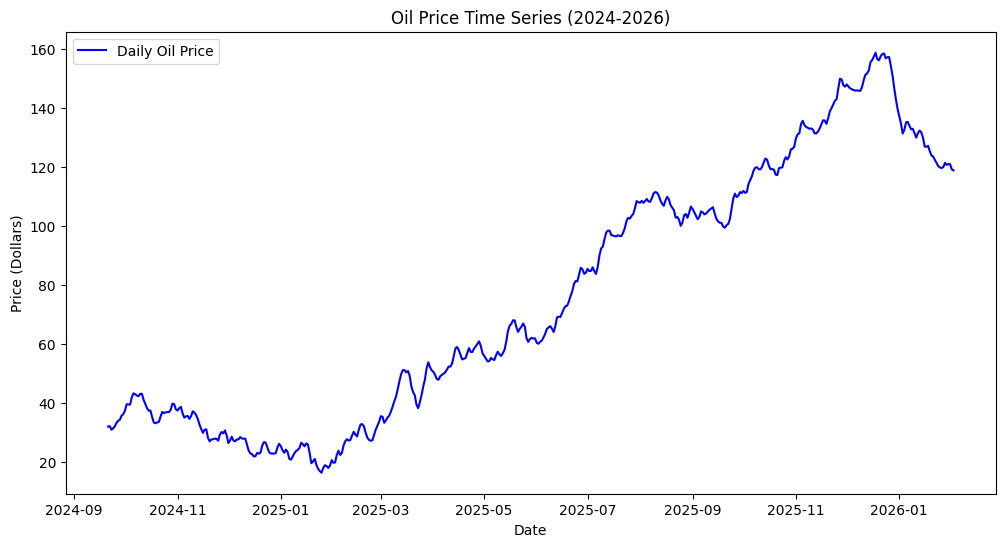

--- Summary Statistics ---
       price (dollars)
count       500.000000
mean         75.873980
std          42.912398
min          16.480000
25%          35.372500
50%          64.290000
75%         111.572500
max         158.780000

Missing values: price (dollars)    0
dtype: int64


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")




df = pd.read_csv('oil_prices_2426.csv',
                 parse_dates=['date'],
                 dayfirst=True)

df.set_index('date', inplace=True)

df = df.asfreq('D')

# 2. EDA - Initial Plot
plt.figure(figsize=(12, 6))
plt.plot(df['price (dollars)'], color='blue', label='Daily Oil Price')
plt.title('Oil Price Time Series (2024-2026)')
plt.xlabel('Date')
plt.ylabel('Price (Dollars)')
plt.legend()
plt.savefig('oil_price_time_series.png')
plt.show()

# 3. Summary Statistics
print("--- Summary Statistics ---")
print(df.describe())

# Check for missing values
print("\nMissing values:", df.isnull().sum())
df['price (dollars)'] = df['price (dollars)'].interpolate(method='linear')

## Test for Non-Stationarity

Testing Original Data:
ADF Statistic: -0.5462340182601634
p-value: 0.8826741397403068
Result: Non-Stationary (Fail to Reject Null Hypothesis)


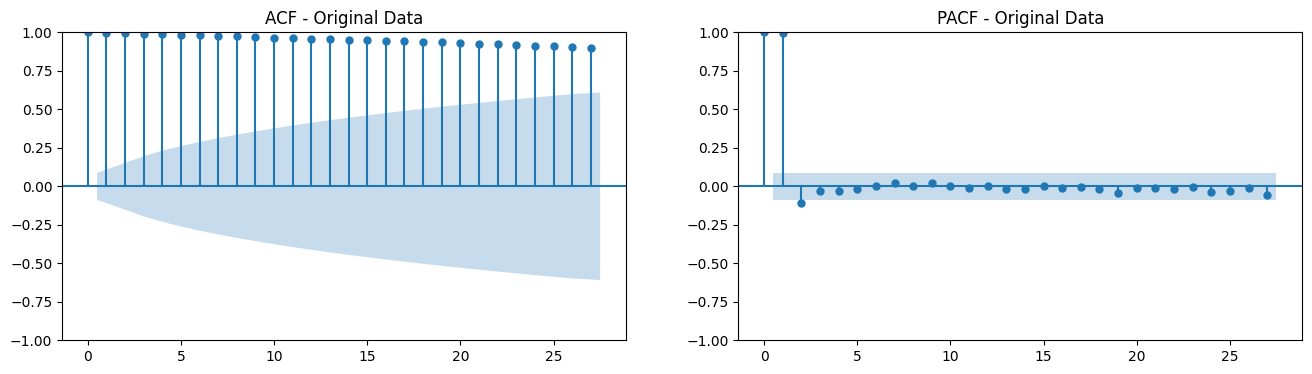

In [6]:
# Function to perform Augmented Dickey-Fuller test
def check_stationarity(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print("Result: Stationary (Reject Null Hypothesis)")
    else:
        print("Result: Non-Stationary (Fail to Reject Null Hypothesis)")

print("Testing Original Data:")
check_stationarity(df['price (dollars)'])

# Plot ACF and PACF for the original data
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df['price (dollars)'], ax=axes[0], title="ACF - Original Data")
plot_pacf(df['price (dollars)'], ax=axes[1], title="PACF - Original Data")
plt.savefig('acf_pacf_original.png')
plt.savefig('pacf_original.png')
plt.show()

## Making Data Stationary

Testing Differenced Data (d=1):
ADF Statistic: -4.541460173486703
p-value: 0.00016536459860957148
Result: Stationary (Reject Null Hypothesis)


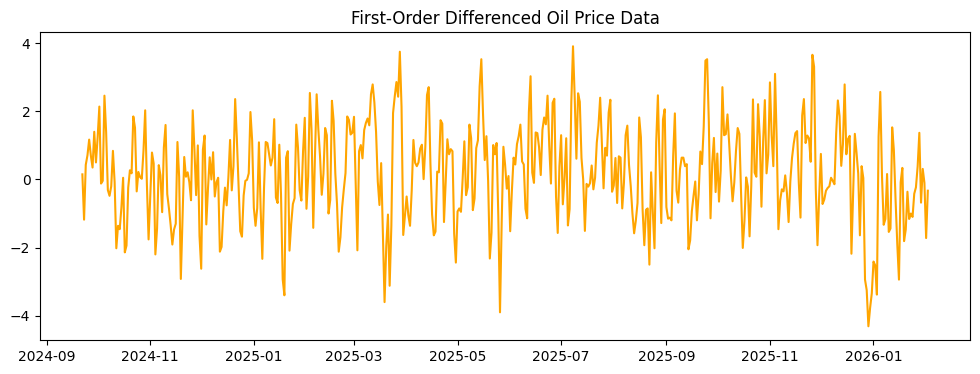

In [7]:
df_diff = df['price (dollars)'].diff().dropna()

print("Testing Differenced Data (d=1):")
check_stationarity(df_diff)

# Plot the differenced data
plt.figure(figsize=(12, 4))
plt.plot(df_diff, color='orange')
plt.title('First-Order Differenced Oil Price Data')
plt.savefig('first_order_differenced.png')
plt.show()

## The AIC Parameter Loop (Finding best p, d, q)

In [8]:
best_aic = np.inf
best_order = None
best_model_res = None

# Defining ranges
p_values = range(0, 9) # 0 to 8
d_values = range(0, 3) # 0 to 2
q_values = range(0, 9) # 0 to 8

print("Starting AIC Loop... please wait.")

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                # Fit ARIMA(p, d, q)
                model = ARIMA(df['price (dollars)'], order=(p, d, q))
                results = model.fit()

                if results.aic < best_aic:
                    best_aic = results.aic
                    best_order = (p, d, q)
                    best_model_res = results
            except:
                continue

print(f"\nLoop Finished!")
print(f"Best ARIMA Order: {best_order}")
print(f"Best AIC Score: {best_aic}")

Starting AIC Loop... please wait.

Loop Finished!
Best ARIMA Order: (2, 2, 7)
Best AIC Score: 1429.357098586032


## Residual Analysis

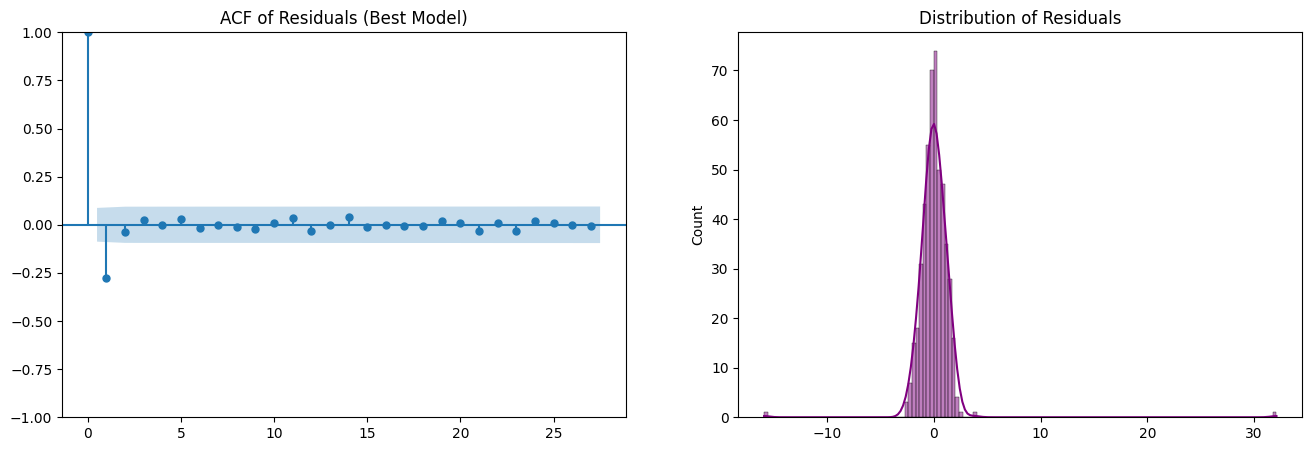

--- Residuals Summary Statistics ---
count    500.000000
mean       0.044894
std        1.886386
min      -15.900014
25%       -0.633432
50%        0.015341
75%        0.717080
max       32.100000
dtype: float64


In [9]:
# 1. Residuals from the best model
residuals = best_model_res.resid

# 2. Plot Residuals ACF and Distribution
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# ACF Plot of Residuals
plot_acf(residuals, ax=ax[0], title="ACF of Residuals (Best Model)")

# Distribution Plot
sns.histplot(residuals, kde=True, ax=ax[1], color='purple')
ax[1].set_title('Distribution of Residuals')
plt.savefig('residuals_analysis.png')
plt.savefig('residuals_acf.png')
plt.show()

# 3. Summary of residuals
print("--- Residuals Summary Statistics ---")
print(residuals.describe())

## Testing Performance using RMSE

Test Set RMSE: 14.777774938847145


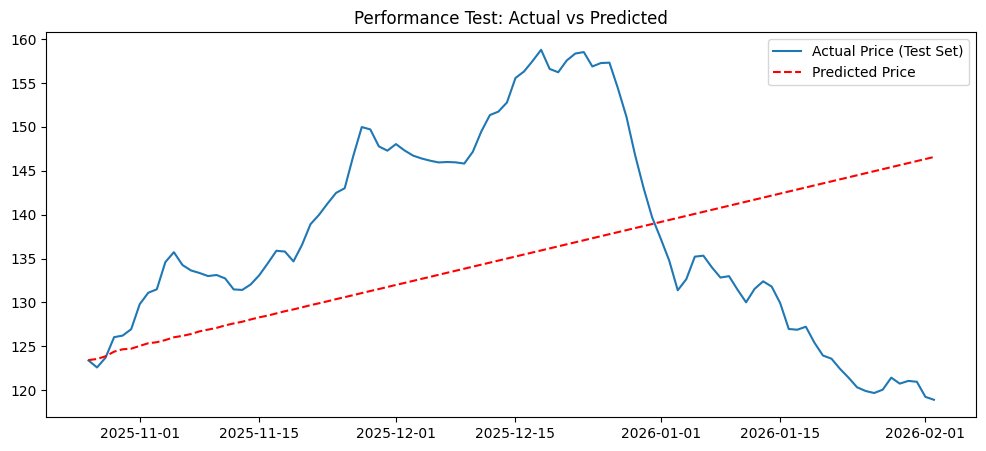

In [10]:
train_size = int(len(df) * 0.8)
train, test = df['price (dollars)'][0:train_size], df['price (dollars)'][train_size:]

# 2. Fit the 'Best' model (2, 2, 7) to the training data
model_train = ARIMA(train, order=(2, 2, 7))
model_train_fit = model_train.fit()

# 3. Forecast for the length of the test set
test_forecast = model_train_fit.forecast(steps=len(test))

# 4. Calculate RMSE
rmse = np.sqrt(mean_squared_error(test, test_forecast))
print(f"Test Set RMSE: {rmse}")

# 5. Plot Actual vs Predicted for the Test period
plt.figure(figsize=(12, 5))
plt.plot(test.index, test, label='Actual Price (Test Set)')
plt.plot(test.index, test_forecast, label='Predicted Price', color='red', linestyle='--')
plt.title('Performance Test: Actual vs Predicted')
plt.legend()
plt.savefig('performance_test.png')
plt.show()

## Forecast 24 Months into the Future

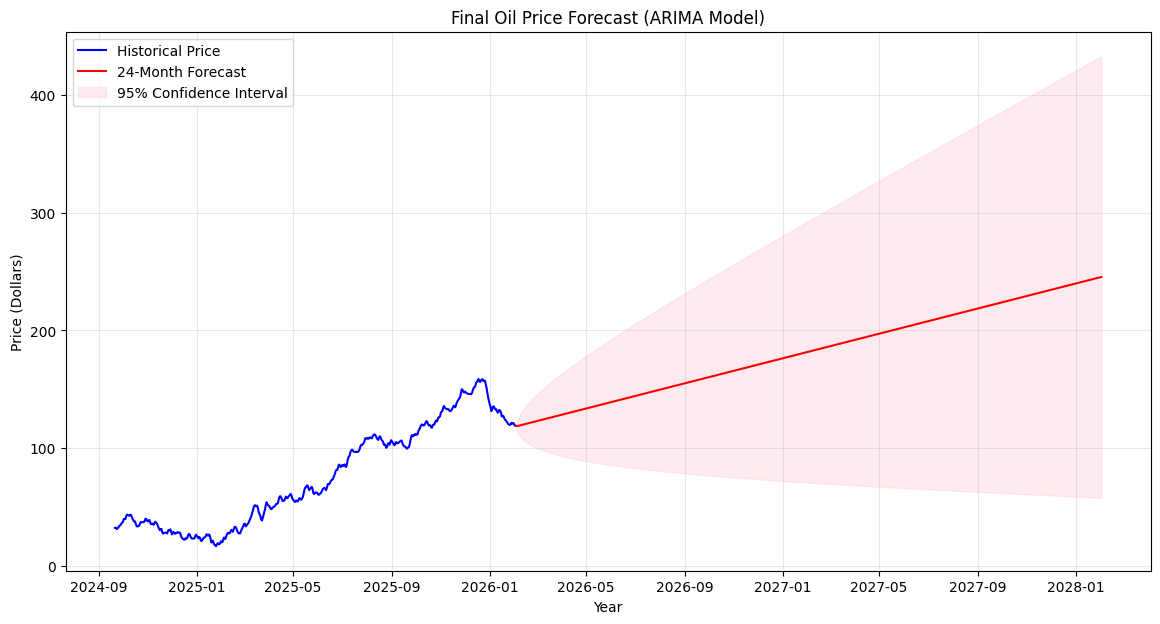

In [11]:
# 1. Define forecast for 24 months
forecast_steps = 730

# 2. Forecast and confidence intervals from the best_model_res
forecast_obj = best_model_res.get_forecast(steps=forecast_steps)
forecast_mean = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

# 3. Create a date index for the forecast
last_date = df.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps)

# 4. Plot the results
plt.figure(figsize=(14, 7))

# Plot historical data
plt.plot(df.index, df['price (dollars)'], label='Historical Price', color='blue')

# Plot forecasted mean
plt.plot(forecast_dates, forecast_mean, label='24-Month Forecast', color='red')

# Plot Confidence Intervals
plt.fill_between(forecast_dates,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title('Final Oil Price Forecast (ARIMA Model)')
plt.xlabel('Year')
plt.ylabel('Price (Dollars)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.savefig('final_forecast.png')
plt.show()



# PART 2

In [12]:
!pip install prophet

## Data Preparation

In [14]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import itertools

# 1. Prepare data for Prophet
df_prophet = df.reset_index()
df_prophet = df_prophet.rename(columns={'date': 'ds', 'price (dollars)': 'y'})

# 2. Split into Train and Test (same split as Part 1 for a fair comparison)
train_prophet = df_prophet.iloc[:train_size]
test_prophet = df_prophet.iloc[train_size:]

## Hyperparameter Tuning with Grid Search

In [15]:
# Define the parameter grid
param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
}

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = []  # Store the RMSEs for each params here

print(f"Starting Hyperparameter Tuning for {len(all_params)} combinations...")

# Simple Grid Search using the Test set
for params in all_params:
    m = Prophet(**params).fit(train_prophet)  # Fit model with given params
    forecast = m.predict(test_prophet)

    # Calculate RMSE for this combination
    current_rmse = np.sqrt(mean_squared_error(test_prophet['y'], forecast['yhat']))
    rmses.append(current_rmse)

# Find the best parameters
tuning_results = pd.DataFrame(all_params)
tuning_results['rmse'] = rmses
best_params = all_params[np.argmin(rmses)]

print("\nBest Parameters found:")
print(best_params)

Starting Hyperparameter Tuning for 16 combinations...


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override 


Best Parameters found:
{'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0}


##  Final Model & Future Forecast

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


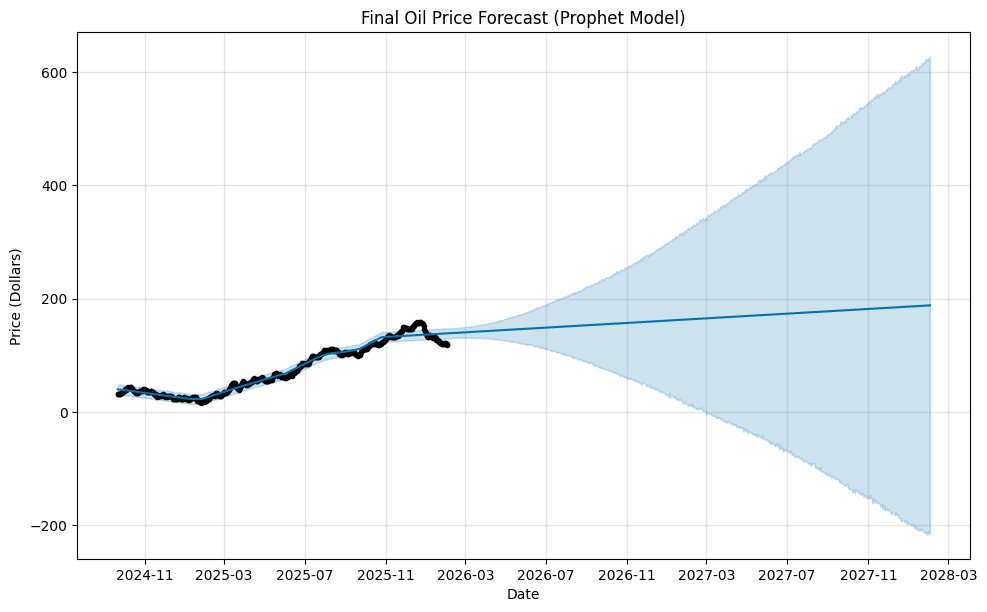

In [18]:
# 1. Fit the final model using best parameters on the FULL dataset
model_final = Prophet(**best_params)
model_final.fit(df_prophet)

# 2. Create future dates (24 months / 730 days)
future = model_final.make_future_dataframe(periods=730)

# 3. Predict the future
forecast_prophet = model_final.predict(future)

# 4. Plot the forecast
fig1 = model_final.plot(forecast_prophet)
plt.title('Final Oil Price Forecast (Prophet Model)')
plt.xlabel('Date')
plt.ylabel('Price (Dollars)')
plt.savefig('final_forecast_prophet.png')
plt.show()

## Comparison & Evaluation

In [19]:
# Get the best RMSE from our tuning
best_prophet_rmse = min(rmses)

print(f"ARIMA (Part 1) RMSE: {rmse}")
print(f"Prophet (Part 2) RMSE: {best_prophet_rmse}")

if best_prophet_rmse < rmse:
    print("Conclusion: Prophet performed better than ARIMA.")
else:
    print("Conclusion: ARIMA performed better than Prophet.")

ARIMA (Part 1) RMSE: 14.777774938847145
Prophet (Part 2) RMSE: 18.384656542574337
Conclusion: ARIMA performed better than Prophet.


##  Model Components

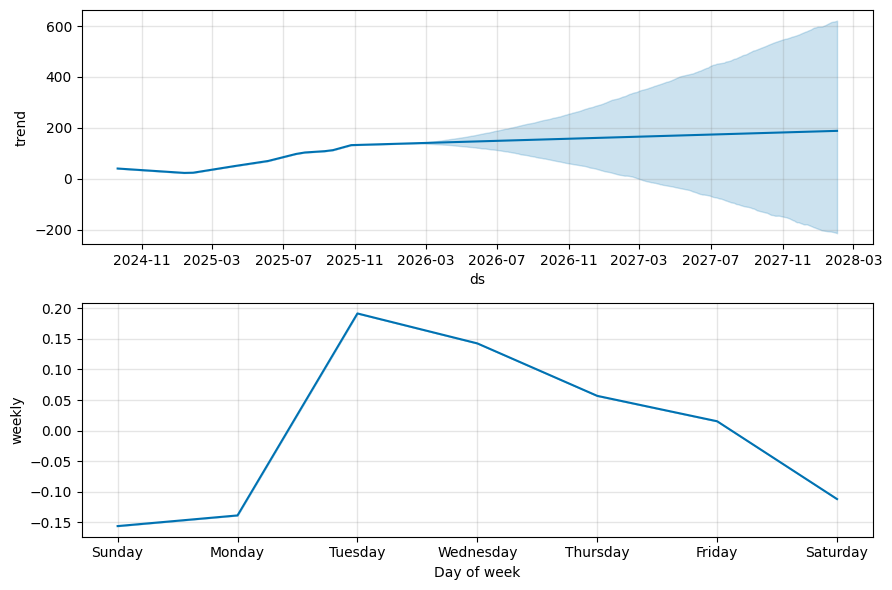

In [20]:
# Plot components: Trend, Weekly seasonality, Yearly seasonality
fig2 = model_final.plot_components(forecast_prophet)
plt.savefig('model_components.png')
plt.show()